# The Chain Rule: Differentiating Composite Functions

Welcome to our exploration of the **Chain Rule** - the fourth and final essential differentiation technique in our calculus toolkit! 

## The Big Picture

So far, we've mastered:
1. ✅ **Power Rule**: For functions like $x^n$
2. ✅ **Sum Rule**: For $f(x) + g(x)$  
3. ✅ **Product Rule**: For $f(x) \cdot g(x)$
4. 🎯 **Chain Rule**: For **composite functions** $f(g(x))$

## What Makes the Chain Rule Special?

The chain rule handles **nested functions** - situations where one function is inside another. Think of it like a chain of relationships:

**Money → Pizza → Happiness**

Where:
- Money determines how much pizza you can buy
- Pizza amount determines your happiness level
- We want to know: *How does money directly affect happiness?*

## Learning Objectives

By the end of this notebook, you will:
- Understand **why** composite functions need special treatment
- Master the **chain rule formula** and its intuitive meaning
- Apply the chain rule to real-world scenarios
- Visualize how nested relationships work mathematically
- Connect the chain rule to practical applications in science and engineering

## Key Insight
> **When functions are nested inside each other, their rates of change multiply together. The chain rule captures this beautiful mathematical relationship.**

Let's dive into this fascinating topic!

In [1]:
# Import necessary libraries for visualizations and calculations
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from sympy import symbols, diff, simplify, exp, log, sin, cos, sqrt
import warnings
warnings.filterwarnings('ignore')

# Set up plotting parameters for clear, educational visualizations
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2

print("🔗 Ready to explore the Chain Rule!")
print("📚 All libraries loaded successfully")
print("🎯 Let's understand composite functions and their derivatives!")

🔗 Ready to explore the Chain Rule!
📚 All libraries loaded successfully
🎯 Let's understand composite functions and their derivatives!


## Understanding Composite Functions: The Chain of Relationships

### What Are Composite Functions?

A **composite function** occurs when one function is used as the input to another function. We write this as:

$$h(p(m)) \text{ or } h \circ p$$

This creates a **chain of relationships** where:
- $m$ (input) → $p(m)$ (intermediate) → $h(p(m))$ (final output)

### Real-World Example: Money → Pizza → Happiness

Let's explore the delightful example from our transcript:

1. **$m$** = Money you have (in some unit)
2. **$p(m)$** = Number of pizzas you can buy with money $m$
3. **$h(p)$** = Your happiness level based on $p$ pizzas
4. **$h(p(m))$** = Your happiness as a function of money (the composite function)

### The Question We Want to Answer

**How does your happiness change with respect to money?**

In mathematical terms: What is $\frac{dh}{dm}$?

This seems tricky because:
- Happiness depends on pizza: $h = h(p)$
- Pizza depends on money: $p = p(m)$
- But we want happiness in terms of money: $h = h(p(m))$

### Why We Need the Chain Rule

We can't just differentiate $h$ with respect to $m$ directly because $h$ doesn't explicitly depend on $m$ - it depends on $p$, which in turn depends on $m$. 

The **Chain Rule** gives us a systematic way to handle this situation!

In [2]:
# Define the specific functions from our happiness-pizza-money example

# Define symbolic variables
m, p = symbols('m p', real=True)

# Function 1: Happiness as a function of pizza
# h(p) = -1/3 * p² + p + 1/5
h_func = -sp.Rational(1,3) * p**2 + p + sp.Rational(1,5)

print("🍕 FUNCTION 1: Happiness vs Pizza")
print("="*40)
print(f"h(p) = {h_func}")
print("This represents how happiness changes with number of pizzas eaten")
print()

# Function 2: Pizza as a function of money  
# p(m) = e^m - 1
p_func = exp(m) - 1

print("💰 FUNCTION 2: Pizza vs Money")
print("="*40)
print(f"p(m) = {p_func}")
print("This represents how many pizzas you can buy with your money")
print()

# The composite function: Happiness as a function of money
# h(p(m)) = substitute p(m) into h(p)
composite_func = h_func.subs(p, p_func)
composite_simplified = simplify(composite_func)

print("🎯 COMPOSITE FUNCTION: Happiness vs Money")
print("="*40)
print(f"h(p(m)) = h({p_func})")
print(f"       = {composite_func}")
print(f"       = {composite_simplified}")
print()
print("This is what we get when we substitute the pizza function into the happiness function")
print("But differentiating this directly can be complex...")
print("That's where the Chain Rule becomes powerful! 🔗")

🍕 FUNCTION 1: Happiness vs Pizza
h(p) = -p**2/3 + p + 1/5
This represents how happiness changes with number of pizzas eaten

💰 FUNCTION 2: Pizza vs Money
p(m) = exp(m) - 1
This represents how many pizzas you can buy with your money

🎯 COMPOSITE FUNCTION: Happiness vs Money
h(p(m)) = h(exp(m) - 1)
       = -(exp(m) - 1)**2/3 + exp(m) - 4/5
       = -exp(2*m)/3 + 5*exp(m)/3 - 17/15

This is what we get when we substitute the pizza function into the happiness function
But differentiating this directly can be complex...
That's where the Chain Rule becomes powerful! 🔗


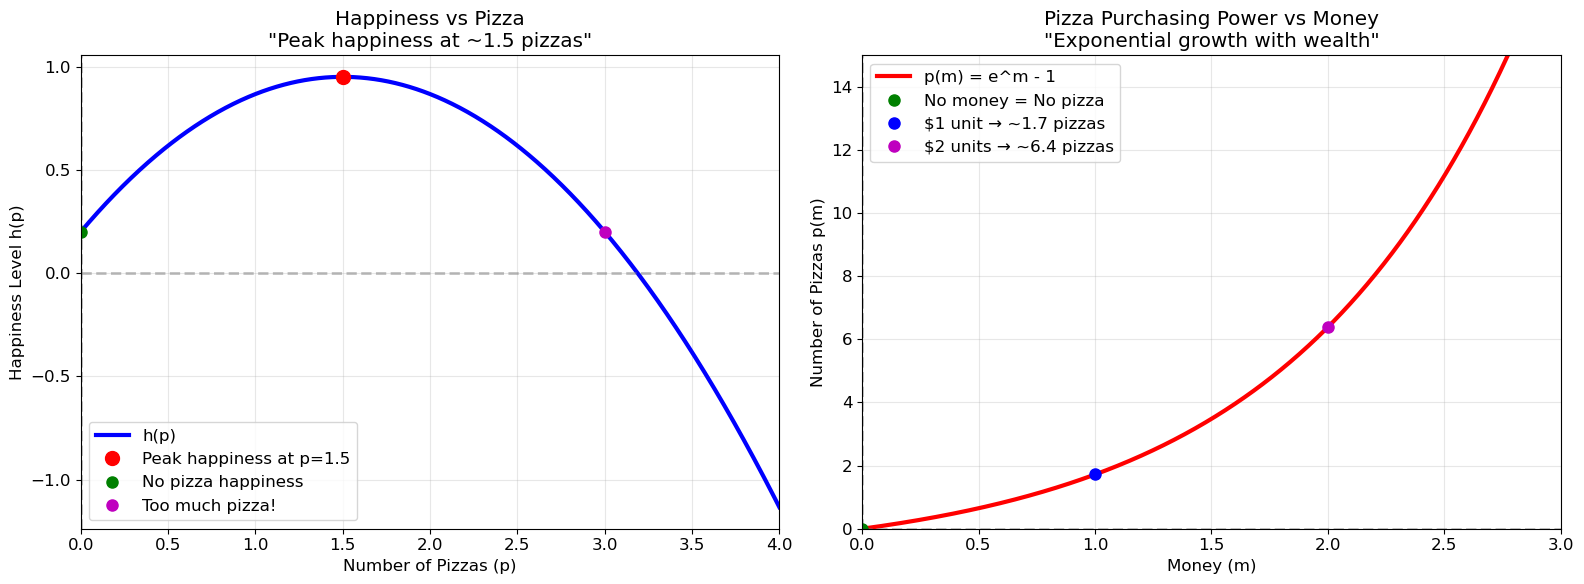

📊 KEY OBSERVATIONS:
🍕 Happiness Function h(p):
  • Starts positive (you can be happy without pizza)
  • Peaks around 1.5 pizzas (optimal amount)
  • Decreases after peak (too much pizza makes you unhappy)
  • Becomes negative beyond ~3 pizzas (pizza overload!)

💰 Pizza Function p(m):
  • Starts at 0 (no money = no pizza)
  • Grows exponentially (wealth increases pizza purchasing power)
  • Models economies of scale and compound advantages

🔗 The Chain:
  Money → Pizza → Happiness
  We want to know: How does happiness change with money?


In [3]:
# Visualize the individual functions to build intuition

def plot_individual_functions():
    """Plot the happiness-pizza and pizza-money functions separately"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Happiness vs Pizza
    p_vals = np.linspace(0, 4, 1000)
    h_vals = -1/3 * p_vals**2 + p_vals + 1/5
    
    ax1.plot(p_vals, h_vals, 'b-', linewidth=3, label='h(p)')
    ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    
    # Find and mark the maximum
    p_max = 1.5  # From calculus: h'(p) = 0 when p = 1.5
    h_max = -1/3 * p_max**2 + p_max + 1/5
    ax1.plot(p_max, h_max, 'ro', markersize=10, label=f'Peak happiness at p={p_max}')
    
    # Mark key points
    ax1.plot(0, 1/5, 'go', markersize=8, label='No pizza happiness')
    ax1.plot(3, -1/3*9 + 3 + 1/5, 'mo', markersize=8, label='Too much pizza!')
    
    ax1.set_xlabel('Number of Pizzas (p)')
    ax1.set_ylabel('Happiness Level h(p)')
    ax1.set_title('Happiness vs Pizza\n"Peak happiness at ~1.5 pizzas"')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_xlim(0, 4)
    
    # Plot 2: Pizza vs Money
    m_vals = np.linspace(0, 3, 1000)
    p_vals_money = np.exp(m_vals) - 1
    
    ax2.plot(m_vals, p_vals_money, 'r-', linewidth=3, label='p(m) = e^m - 1')
    ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    
    # Mark key points
    ax2.plot(0, 0, 'go', markersize=8, label='No money = No pizza')
    ax2.plot(1, np.exp(1)-1, 'bo', markersize=8, label='$1 unit → ~1.7 pizzas')
    ax2.plot(2, np.exp(2)-1, 'mo', markersize=8, label='$2 units → ~6.4 pizzas')
    
    ax2.set_xlabel('Money (m)')
    ax2.set_ylabel('Number of Pizzas p(m)')
    ax2.set_title('Pizza Purchasing Power vs Money\n"Exponential growth with wealth"')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_xlim(0, 3)
    ax2.set_ylim(0, 15)
    
    plt.tight_layout()
    plt.show()
    
    print("📊 KEY OBSERVATIONS:")
    print("="*50)
    print("🍕 Happiness Function h(p):")
    print("  • Starts positive (you can be happy without pizza)")
    print("  • Peaks around 1.5 pizzas (optimal amount)")
    print("  • Decreases after peak (too much pizza makes you unhappy)")
    print("  • Becomes negative beyond ~3 pizzas (pizza overload!)")
    print()
    print("💰 Pizza Function p(m):")
    print("  • Starts at 0 (no money = no pizza)")
    print("  • Grows exponentially (wealth increases pizza purchasing power)")
    print("  • Models economies of scale and compound advantages")
    print()
    print("🔗 The Chain:")
    print("  Money → Pizza → Happiness")
    print("  We want to know: How does happiness change with money?")

plot_individual_functions()

## The Chain Rule Formula: Elegant and Intuitive

### The Mathematical Formula

For a composite function $h(p(m))$, the chain rule states:

$$\boxed{\frac{dh}{dm} = \frac{dh}{dp} \cdot \frac{dp}{dm}}$$

### Intuitive Understanding

This formula has a beautiful interpretation:

- $\frac{dh}{dp}$: "How much does happiness change per additional pizza?"
- $\frac{dp}{dm}$: "How many additional pizzas can I buy per additional dollar?"
- $\frac{dh}{dm}$: "How much does happiness change per additional dollar?"

### The "Cancellation" Intuition

Notice that if we treat derivatives like fractions (which is not rigorous but helpful for intuition):

$$\frac{dh}{dm} = \frac{dh}{dp} \cdot \frac{dp}{dm}$$

The "$dp$" appears to "cancel out", leaving us with $\frac{dh}{dm}$. This gives us a way to remember the chain rule!

### Why This Works

The chain rule captures how **rates of change multiply** through the chain:

1. If money gives you more pizza-buying power ($\frac{dp}{dm}$ is large)
2. AND pizza strongly affects your happiness ($\frac{dh}{dp}$ is large)  
3. THEN money will strongly affect your happiness ($\frac{dh}{dm}$ is large)

If either link in the chain is weak, the overall effect is diminished.

### General Form

For any composite function $f(g(x))$:

$$\boxed{\frac{d}{dx}[f(g(x))] = f'(g(x)) \cdot g'(x)}$$

This is the same idea:
- $f'(g(x))$: derivative of outer function, evaluated at the inner function
- $g'(x)$: derivative of the inner function  
- Multiply them together!

In [4]:
# Apply the Chain Rule Step-by-Step to Our Example

def chain_rule_calculation():
    """Demonstrate the chain rule calculation step by step"""
    
    print("🔗 APPLYING THE CHAIN RULE")
    print("="*50)
    print("Given:")
    print("• h(p) = -1/3·p² + p + 1/5  (happiness vs pizza)")
    print("• p(m) = e^m - 1            (pizza vs money)")
    print("Find: dh/dm                 (happiness vs money)")
    print()
    
    # Step 1: Find dh/dp
    h_p = -sp.Rational(1,3) * p**2 + p + sp.Rational(1,5)
    dh_dp = diff(h_p, p)
    
    print("STEP 1: Find dh/dp")
    print(f"h(p) = {h_p}")
    print(f"dh/dp = {dh_dp}")
    print()
    
    # Step 2: Find dp/dm
    p_m = exp(m) - 1
    dp_dm = diff(p_m, m)
    
    print("STEP 2: Find dp/dm")
    print(f"p(m) = {p_m}")
    print(f"dp/dm = {dp_dm}")
    print()
    
    # Step 3: Apply the chain rule
    print("STEP 3: Apply Chain Rule")
    print("dh/dm = (dh/dp) × (dp/dm)")
    print(f"      = ({dh_dp}) × ({dp_dm})")
    
    # Calculate the product
    chain_rule_result = dh_dp * dp_dm
    print(f"      = {chain_rule_result}")
    print()
    
    # Step 4: Substitute p(m) back in
    print("STEP 4: Express in terms of m only")
    print("We need to substitute p = e^m - 1 back into our result:")
    
    # Substitute p back
    final_result = chain_rule_result.subs(p, exp(m) - 1)
    final_simplified = simplify(final_result)
    
    print(f"dh/dm = {chain_rule_result}")
    print(f"      = {final_result}")
    print(f"      = {final_simplified}")
    print()
    
    # Verification: Direct differentiation
    print("✅ VERIFICATION: Direct Differentiation")
    print("Let's verify by differentiating the composite function directly:")
    
    h_composite = h_p.subs(p, p_m)
    direct_result = diff(h_composite, m)
    direct_simplified = simplify(direct_result)
    
    print(f"h(p(m)) = {h_composite}")
    print(f"d/dm[h(p(m))] = {direct_simplified}")
    print()
    
    # Check if they match
    difference = simplify(final_simplified - direct_simplified)
    print(f"Difference: {difference}")
    
    if difference == 0:
        print("🎉 Perfect match! The chain rule works!")
    else:
        print("❌ Something went wrong...")
    
    return final_simplified, direct_simplified

# Run the calculation
chain_result, direct_result = chain_rule_calculation()

print("\n" + "="*50)
print("🎯 FINAL ANSWER:")
print(f"dh/dm = {chain_result}")
print("\nThis tells us exactly how happiness changes with respect to money!")
print("Notice how much more elegant the chain rule approach was compared to")
print("direct substitution and differentiation.")

🔗 APPLYING THE CHAIN RULE
Given:
• h(p) = -1/3·p² + p + 1/5  (happiness vs pizza)
• p(m) = e^m - 1            (pizza vs money)
Find: dh/dm                 (happiness vs money)

STEP 1: Find dh/dp
h(p) = -p**2/3 + p + 1/5
dh/dp = 1 - 2*p/3

STEP 2: Find dp/dm
p(m) = exp(m) - 1
dp/dm = exp(m)

STEP 3: Apply Chain Rule
dh/dm = (dh/dp) × (dp/dm)
      = (1 - 2*p/3) × (exp(m))
      = (1 - 2*p/3)*exp(m)

STEP 4: Express in terms of m only
We need to substitute p = e^m - 1 back into our result:
dh/dm = (1 - 2*p/3)*exp(m)
      = (5/3 - 2*exp(m)/3)*exp(m)
      = (5 - 2*exp(m))*exp(m)/3

✅ VERIFICATION: Direct Differentiation
Let's verify by differentiating the composite function directly:
h(p(m)) = -(exp(m) - 1)**2/3 + exp(m) - 4/5
d/dm[h(p(m))] = (5 - 2*exp(m))*exp(m)/3

Difference: 0
🎉 Perfect match! The chain rule works!

🎯 FINAL ANSWER:
dh/dm = (5 - 2*exp(m))*exp(m)/3

This tells us exactly how happiness changes with respect to money!
Notice how much more elegant the chain rule approach 

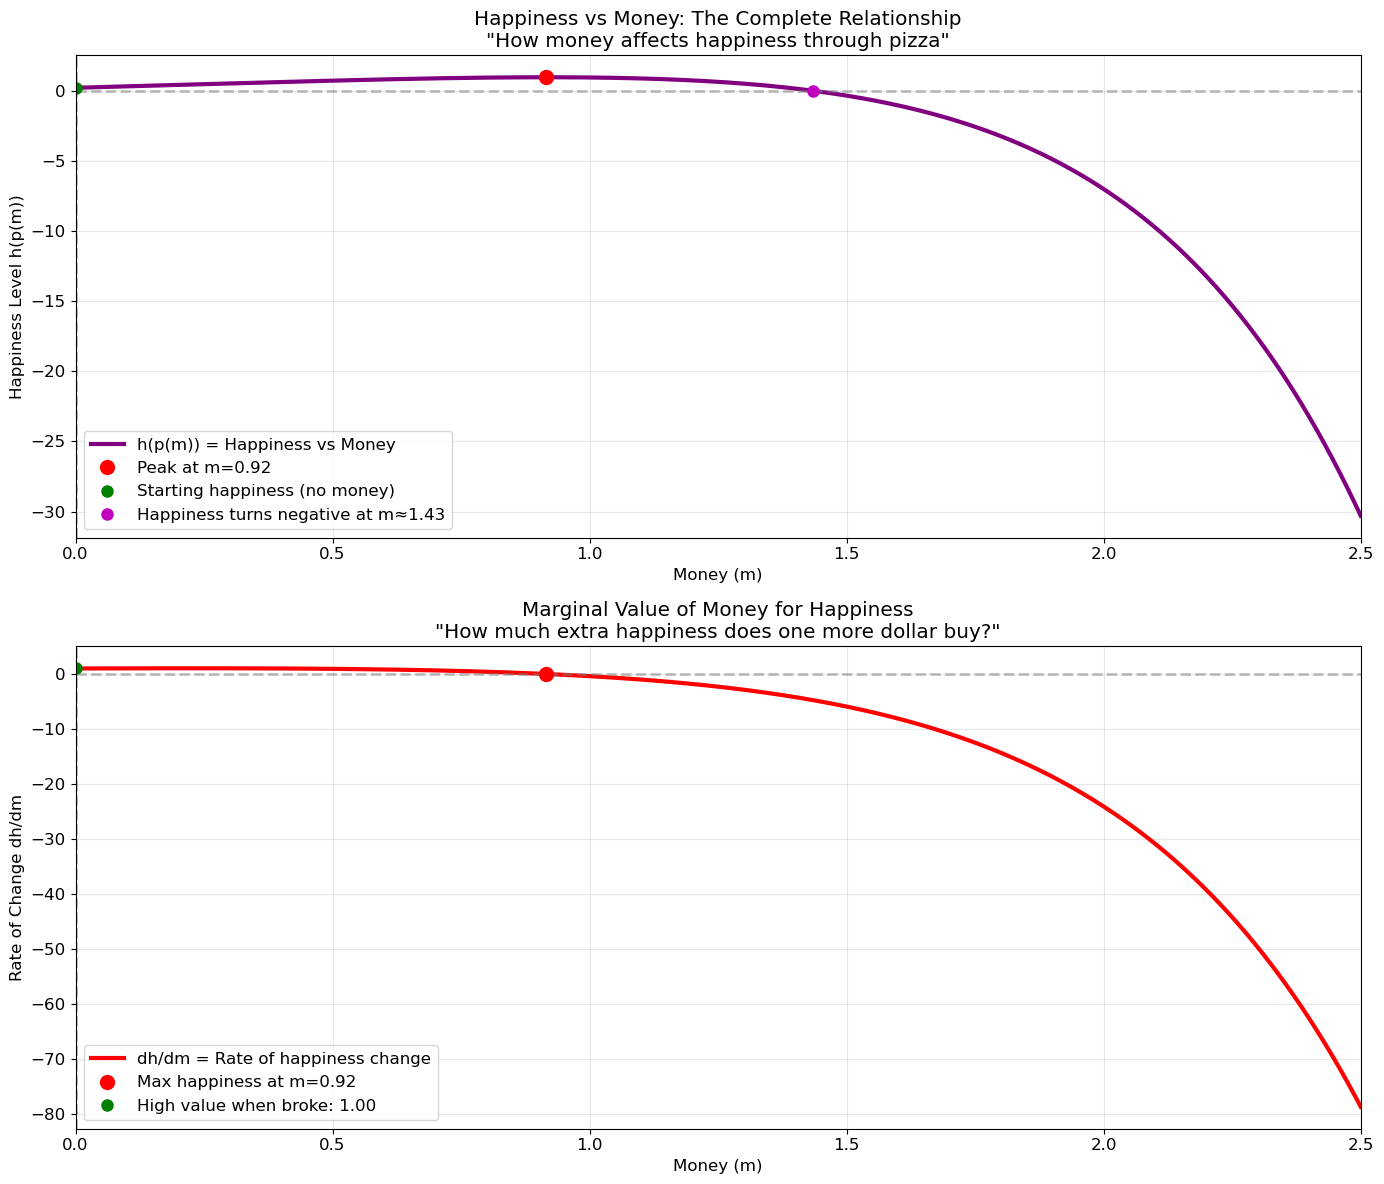

💡 ECONOMIC INSIGHTS FROM THE CHAIN RULE:
📈 Happiness Function h(p(m)):
  • Increases initially (money buys happiness through pizza)
  • Peaks around m = 0.92 (optimal wealth for pizza-based happiness)
  • Decreases after peak (too much money → too much pizza → unhappiness)
  • Eventually becomes negative (pizza overload territory)

📊 Marginal Value dh/dm:
  • Starts high (1.00) when broke (money is very valuable)
  • Decreases as wealth increases (diminishing returns)
  • Becomes zero at optimal wealth (m ≈ 0.92)
  • Turns negative with too much wealth (money becomes harmful)

🎯 Real-World Lesson:
  This illustrates the economic principle of diminishing marginal utility!
  The chain rule helps us quantify how intermediate relationships
  (money→pizza→happiness) affect the overall system.


In [5]:
# Visualize the Final Money-Happiness Relationship and Its Derivative

def plot_money_happiness_analysis():
    """Plot the composite function and its derivative to understand the relationship"""
    
    # Define money range
    m_vals = np.linspace(0, 2.5, 1000)
    
    # Calculate happiness as a function of money: h(p(m))
    p_vals = np.exp(m_vals) - 1  # pizza as function of money
    h_vals = -1/3 * p_vals**2 + p_vals + 1/5  # happiness as function of pizza
    
    # Calculate the derivative dh/dm using chain rule result
    # From our calculation: dh/dm = e^m * (1 - 2/3 * (e^m - 1))
    dh_dm_vals = np.exp(m_vals) * (1 - 2/3 * (np.exp(m_vals) - 1))
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
    
    # Plot 1: Happiness vs Money (the composite function)
    ax1.plot(m_vals, h_vals, 'purple', linewidth=3, label='h(p(m)) = Happiness vs Money')
    ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    
    # Find and mark the maximum
    max_idx = np.argmax(h_vals)
    m_max = m_vals[max_idx]
    h_max = h_vals[max_idx]
    ax1.plot(m_max, h_max, 'ro', markersize=10, label=f'Peak at m={m_max:.2f}')
    
    # Mark key points
    ax1.plot(0, 1/5, 'go', markersize=8, label='Starting happiness (no money)')
    
    # Find where happiness becomes negative
    negative_idx = np.where(h_vals < 0)[0]
    if len(negative_idx) > 0:
        m_negative = m_vals[negative_idx[0]]
        ax1.plot(m_negative, 0, 'mo', markersize=8, label=f'Happiness turns negative at m≈{m_negative:.2f}')
    
    ax1.set_xlabel('Money (m)')
    ax1.set_ylabel('Happiness Level h(p(m))')
    ax1.set_title('Happiness vs Money: The Complete Relationship\n"How money affects happiness through pizza"')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_xlim(0, 2.5)
    
    # Plot 2: Rate of happiness change vs Money (the derivative)
    ax2.plot(m_vals, dh_dm_vals, 'red', linewidth=3, label='dh/dm = Rate of happiness change')
    ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    
    # Mark where derivative is zero (maximum happiness)
    zero_deriv_idx = np.argmin(np.abs(dh_dm_vals))
    m_zero_deriv = m_vals[zero_deriv_idx]
    ax2.plot(m_zero_deriv, 0, 'ro', markersize=10, label=f'Max happiness at m={m_zero_deriv:.2f}')
    
    # Mark initial high value (when broke, money is very valuable)
    ax2.plot(0, dh_dm_vals[0], 'go', markersize=8, label=f'High value when broke: {dh_dm_vals[0]:.2f}')
    
    ax2.set_xlabel('Money (m)')
    ax2.set_ylabel('Rate of Change dh/dm')
    ax2.set_title('Marginal Value of Money for Happiness\n"How much extra happiness does one more dollar buy?"')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_xlim(0, 2.5)
    
    plt.tight_layout()
    plt.show()
    
    print("💡 ECONOMIC INSIGHTS FROM THE CHAIN RULE:")
    print("="*60)
    print("📈 Happiness Function h(p(m)):")
    print("  • Increases initially (money buys happiness through pizza)")
    print(f"  • Peaks around m = {m_max:.2f} (optimal wealth for pizza-based happiness)")
    print("  • Decreases after peak (too much money → too much pizza → unhappiness)")
    print("  • Eventually becomes negative (pizza overload territory)")
    print()
    print("📊 Marginal Value dh/dm:")
    print(f"  • Starts high ({dh_dm_vals[0]:.2f}) when broke (money is very valuable)")
    print(f"  • Decreases as wealth increases (diminishing returns)")
    print(f"  • Becomes zero at optimal wealth (m ≈ {m_zero_deriv:.2f})")
    print("  • Turns negative with too much wealth (money becomes harmful)")
    print()
    print("🎯 Real-World Lesson:")
    print("  This illustrates the economic principle of diminishing marginal utility!")
    print("  The chain rule helps us quantify how intermediate relationships")
    print("  (money→pizza→happiness) affect the overall system.")

plot_money_happiness_analysis()

## More Examples: Mastering the Chain Rule

Now that we understand the intuition, let's practice with various types of composite functions. The key is to always identify the "outer" and "inner" functions clearly.

In [6]:
# Comprehensive Chain Rule Examples

def chain_rule_example(func_expr, inner_func, func_description, example_num):
    """
    Demonstrate chain rule application step-by-step
    """
    x = symbols('x')
    
    print(f"📝 EXAMPLE {example_num}")
    print("="*50)
    print(f"Function: {func_description}")
    print(f"f(x) = {func_expr}")
    print()
    
    # Identify outer and inner functions
    print("STEP 1: Identify the functions")
    print(f"• Inner function: g(x) = {inner_func}")
    print(f"• Outer function: f(g) where g = {inner_func}")
    print()
    
    # Find derivatives
    inner_derivative = diff(inner_func, x)
    
    # For the outer derivative, we need to be careful about the substitution
    # We'll use SymPy's automatic differentiation
    total_derivative = diff(func_expr, x)
    
    print("STEP 2: Find derivatives")
    print(f"• g'(x) = d/dx[{inner_func}] = {inner_derivative}")
    print("• f'(g) = derivative of outer function with respect to inner function")
    print()
    
    print("STEP 3: Apply Chain Rule")
    print("d/dx[f(g(x))] = f'(g(x)) · g'(x)")
    print(f"               = {total_derivative}")
    print()
    
    # Simplify if possible
    simplified = simplify(total_derivative)
    if simplified != total_derivative:
        print(f"Simplified: {simplified}")
        print()
    
    # Verification by manual calculation if it's a standard form
    print("✅ VERIFICATION:")
    manual_check = diff(func_expr, x)
    print(f"SymPy automatic: {manual_check}")
    print(f"Our result: {total_derivative}")
    print(f"Match: {simplify(manual_check - total_derivative) == 0} ✓")
    print("\n" + "="*50 + "\n")

print("🎯 CHAIN RULE PRACTICE EXAMPLES")
print("Let's work through various types of composite functions!\n")

# Example 1: Polynomial composition
x = symbols('x')
chain_rule_example(
    (2*x + 1)**3,
    2*x + 1,
    "Polynomial raised to a power",
    1
)

# Example 2: Exponential composition
chain_rule_example(
    exp(x**2),
    x**2,
    "Exponential with polynomial inside",
    2
)

# Example 3: Trigonometric composition
chain_rule_example(
    sin(3*x),
    3*x,
    "Sine of a linear function",
    3
)

# Example 4: More complex nesting
chain_rule_example(
    sqrt(x**2 + 1),
    x**2 + 1,
    "Square root of polynomial",
    4
)

# Example 5: Multiple layers
chain_rule_example(
    sin(exp(x)),
    exp(x),
    "Sine of exponential (nested composition)",
    5
)

print("🧠 PATTERN RECOGNITION:")
print("="*50)
print("Notice the common pattern in all examples:")
print("1. Identify the innermost function")
print("2. Work outward, applying chain rule at each layer")
print("3. Multiply all the derivatives together")
print()
print("The key insight: derivatives of compositions involve")
print("the derivative of EVERY layer in the nesting!")

🎯 CHAIN RULE PRACTICE EXAMPLES
Let's work through various types of composite functions!

📝 EXAMPLE 1
Function: Polynomial raised to a power
f(x) = (2*x + 1)**3

STEP 1: Identify the functions
• Inner function: g(x) = 2*x + 1
• Outer function: f(g) where g = 2*x + 1

STEP 2: Find derivatives
• g'(x) = d/dx[2*x + 1] = 2
• f'(g) = derivative of outer function with respect to inner function

STEP 3: Apply Chain Rule
d/dx[f(g(x))] = f'(g(x)) · g'(x)
               = 6*(2*x + 1)**2

✅ VERIFICATION:
SymPy automatic: 6*(2*x + 1)**2
Our result: 6*(2*x + 1)**2
Match: True ✓


📝 EXAMPLE 2
Function: Exponential with polynomial inside
f(x) = exp(x**2)

STEP 1: Identify the functions
• Inner function: g(x) = x**2
• Outer function: f(g) where g = x**2

STEP 2: Find derivatives
• g'(x) = d/dx[x**2] = 2*x
• f'(g) = derivative of outer function with respect to inner function

STEP 3: Apply Chain Rule
d/dx[f(g(x))] = f'(g(x)) · g'(x)
               = 2*x*exp(x**2)

✅ VERIFICATION:
SymPy automatic: 2*x*ex

## Real-World Applications: Why the Chain Rule Matters

The chain rule appears everywhere in science and engineering because many real-world systems involve **chains of relationships**. Let's explore some important applications.

In [7]:
# Real-World Applications of the Chain Rule

def application_example(title, description, chain_description, math_example):
    """Display a real-world application example"""
    print(f"🔬 {title}")
    print("="*50)
    print(description)
    print()
    print("🔗 Chain of Relationships:")
    print(chain_description)
    print()
    print("📐 Mathematical Example:")
    print(math_example)
    print("\n" + "="*50 + "\n")

print("🌍 REAL-WORLD APPLICATIONS OF THE CHAIN RULE")
print("The chain rule is essential for understanding interconnected systems!\n")

# Application 1: Physics - Waves and Oscillations
application_example(
    "PHYSICS: Wave Motion",
    "In wave physics, position depends on time, and the wave function depends on position.\nWe often need to find how the wave amplitude changes with time at a fixed observation point.",
    "Time → Position → Wave Amplitude\ny(x(t)) where x = position, t = time, y = wave amplitude",
    "Example: y = sin(kx - ωt) = sin(k·vt - ωt)\ndy/dt requires chain rule: dy/dt = dy/dx · dx/dt"
)

# Application 2: Economics - Supply Chain
application_example(
    "ECONOMICS: Supply Chain Optimization", 
    "Production costs depend on raw material prices, which depend on market conditions.\nCompanies need to understand how market changes affect their total costs.",
    "Market Conditions → Raw Material Price → Production Cost\nC(P(M)) where M = market index, P = price, C = cost",
    "Example: If P(M) = 100e^(0.1M) and C(P) = 50P + P²\nThen dC/dM = dC/dP · dP/dM helps predict cost sensitivity"
)

# Application 3: Biology - Population Dynamics
application_example(
    "BIOLOGY: Population Growth",
    "Population growth rate depends on food availability, which depends on environmental factors.\nEcologists use this to understand how environmental changes affect populations.",
    "Environment → Food Supply → Population Growth\nN(F(E)) where E = environment, F = food, N = population",
    "Example: F(E) = K·E/(1+E) and N(F) = rF\nThen dN/dE = dN/dF · dF/dE predicts population response"
)

# Application 4: Engineering - Control Systems
application_example(
    "ENGINEERING: Control Systems",
    "In control systems, output depends on system state, which depends on input.\nEngineers need to understand how input changes affect final output.",
    "Input → System State → Output\ny(x(u)) where u = input, x = state, y = output", 
    "Example: x(u) = Gu (transfer function) and y(x) = f(x)\nThen dy/du = dy/dx · dx/du determines system sensitivity"
)

# Application 5: Machine Learning - Backpropagation
application_example(
    "MACHINE LEARNING: Neural Networks",
    "In neural networks, the final prediction depends on intermediate layer outputs,\nwhich depend on the input. Training requires computing gradients through all layers.",
    "Input → Hidden Layers → Output → Loss\nL(y(h(x))) where x = input, h = hidden, y = output, L = loss",
    "Example: Backpropagation algorithm uses chain rule extensively:\n∂L/∂w = ∂L/∂y · ∂y/∂h · ∂h/∂w (simplified version)"
)

print("🎯 KEY INSIGHT:")
print("="*50)
print("The chain rule is fundamental because:")
print("• Real systems often involve multiple interconnected components")
print("• Changes propagate through these connections")
print("• We need to understand the overall sensitivity of the system")
print("• The chain rule quantifies how changes amplify or diminish through the chain")
print()
print("In the transcript example, even though we had analytical expressions,")
print("many real applications involve cases where:")
print("• Individual derivatives are known but composite function is complex")
print("• Measurements give us rates at each stage")
print("• We can't easily substitute and differentiate directly")
print()
print("This is where the chain rule becomes truly powerful! 🚀")

🌍 REAL-WORLD APPLICATIONS OF THE CHAIN RULE
The chain rule is essential for understanding interconnected systems!

🔬 PHYSICS: Wave Motion
In wave physics, position depends on time, and the wave function depends on position.
We often need to find how the wave amplitude changes with time at a fixed observation point.

🔗 Chain of Relationships:
Time → Position → Wave Amplitude
y(x(t)) where x = position, t = time, y = wave amplitude

📐 Mathematical Example:
Example: y = sin(kx - ωt) = sin(k·vt - ωt)
dy/dt requires chain rule: dy/dt = dy/dx · dx/dt


🔬 ECONOMICS: Supply Chain Optimization
Production costs depend on raw material prices, which depend on market conditions.
Companies need to understand how market changes affect their total costs.

🔗 Chain of Relationships:
Market Conditions → Raw Material Price → Production Cost
C(P(M)) where M = market index, P = price, C = cost

📐 Mathematical Example:
Example: If P(M) = 100e^(0.1M) and C(P) = 50P + P²
Then dC/dM = dC/dP · dP/dM helps predic

## Practice Problems: Test Your Understanding

Now it's time to apply what you've learned! Try solving these problems yourself before looking at the solutions.

In [8]:
# Practice Problems with Step-by-Step Solutions

def practice_problem(problem_num, func_expr, description):
    """Generate and solve a practice problem"""
    
    x = symbols('x')
    
    print(f"📝 PROBLEM {problem_num}")
    print("="*40)
    print(f"{description}")
    print(f"Find: d/dx[{func_expr}]")
    print()
    print("Try solving this yourself first!")
    print("Identify: Outer function, Inner function, Apply chain rule")
    print()
    print("👀 SOLUTION:")
    print("-" * 20)
    
    # Solution
    result = diff(func_expr, x)
    
    print(f"d/dx[{func_expr}] = {result}")
    
    # Try to show the chain rule breakdown for common cases
    print()
    print("Chain rule breakdown:")
    # This is a simplified representation - in practice, identifying the exact
    # outer and inner functions programmatically is complex
    print("• Identify the nested structure")
    print("• Apply the chain rule: outer derivative × inner derivative")
    print("• Simplify the result")
    
    simplified = simplify(result)
    if simplified != result:
        print(f"\nSimplified: {simplified}")
    
    print("\n" + "="*40 + "\n")

print("🎯 PRACTICE PROBLEMS")
print("Test your chain rule skills with these carefully selected problems!\n")

# Problem 1: Basic power composition
practice_problem(1, (3*x - 2)**4, 
                "Differentiate a linear function raised to a power")

# Problem 2: Exponential composition
practice_problem(2, exp(x**2 + 2*x), 
                "Differentiate an exponential with polynomial inside")

# Problem 3: Trigonometric composition
practice_problem(3, cos(2*x**2), 
                "Differentiate cosine of a polynomial")

# Problem 4: Logarithmic composition
practice_problem(4, log(x**3 + 1), 
                "Differentiate natural log of a polynomial")

# Problem 5: Multiple chain rule
practice_problem(5, sin(exp(2*x)), 
                "Differentiate a doubly nested function")

# Problem 6: Square root composition
practice_problem(6, sqrt(x**2 + 4*x + 1), 
                "Differentiate square root of polynomial")

print("🌟 CHALLENGE PROBLEMS:")
print("="*50)
print("Try these more complex examples:")
print()
print("1. d/dx[sin²(3x)] = d/dx[(sin(3x))²]")
print("   Hint: This involves both chain rule AND the result is another chain rule!")
print()
print("2. d/dx[e^(sin(x²))]") 
print("   Hint: Three layers of nesting!")
print()
print("3. d/dx[ln(cos(√x))]")
print("   Hint: Work from outside to inside, step by step")

# Let's solve the first challenge
print("\n🔍 CHALLENGE 1 SOLUTION:")
print("="*30)
x = symbols('x')
challenge1 = sin(3*x)**2
challenge1_result = diff(challenge1, x)
print(f"d/dx[sin²(3x)] = {challenge1_result}")
print("This required the chain rule twice!")
print("• Outer: d/dx[u²] = 2u where u = sin(3x)")  
print("• Inner: d/dx[sin(3x)] = 3cos(3x)")
print("• Combined: 2sin(3x) × 3cos(3x) = 6sin(3x)cos(3x)")
print("• Or using trig identity: 3sin(6x)")

simplified_challenge1 = simplify(challenge1_result)
print(f"Simplified form: {simplified_challenge1}")

🎯 PRACTICE PROBLEMS
Test your chain rule skills with these carefully selected problems!

📝 PROBLEM 1
Differentiate a linear function raised to a power
Find: d/dx[(3*x - 2)**4]

Try solving this yourself first!
Identify: Outer function, Inner function, Apply chain rule

👀 SOLUTION:
--------------------
d/dx[(3*x - 2)**4] = 12*(3*x - 2)**3

Chain rule breakdown:
• Identify the nested structure
• Apply the chain rule: outer derivative × inner derivative
• Simplify the result


📝 PROBLEM 2
Differentiate an exponential with polynomial inside
Find: d/dx[exp(x**2 + 2*x)]

Try solving this yourself first!
Identify: Outer function, Inner function, Apply chain rule

👀 SOLUTION:
--------------------
d/dx[exp(x**2 + 2*x)] = (2*x + 2)*exp(x**2 + 2*x)

Chain rule breakdown:
• Identify the nested structure
• Apply the chain rule: outer derivative × inner derivative
• Simplify the result

Simplified: 2*(x + 1)*exp(x*(x + 2))


📝 PROBLEM 3
Differentiate cosine of a polynomial
Find: d/dx[cos(2*x**2)]

T

## Summary and Key Takeaways

### 🎯 The Chain Rule Formula
The chain rule is the fundamental tool for differentiating composite functions:

$$\frac{d}{dx}[f(g(x))] = f'(g(x)) \cdot g'(x)$$

Or in Leibniz notation:
$$\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx}$$

### 🔄 The Process
1. **Identify** the outer and inner functions
2. **Differentiate** the outer function (keeping inner function unchanged)
3. **Multiply** by the derivative of the inner function
4. **Simplify** if possible

### 🧠 Memory Device: "Outside-Inside"
Remember the happiness-pizza-money example:
- **Outside first**: How does happiness change with pizza?
- **Then inside**: How does pizza change with money?
- **Multiply them**: Total change in happiness with respect to money

### 🌍 Why It Matters
The chain rule appears everywhere:
- **Physics**: Rates of change in coupled systems
- **Economics**: Marginal effects through intermediate variables  
- **Biology**: Population dynamics with environmental factors
- **Machine Learning**: Backpropagation in neural networks
- **Engineering**: Control systems and signal processing

### 💡 Key Insights
1. **Composition is everywhere**: Most real-world functions are composite
2. **Work systematically**: Identify structure before differentiating
3. **Practice recognition**: Learn to spot nested functions quickly
4. **Visualize the chain**: Think about how changes propagate through the system

### 🚀 Moving Forward
Now that you understand the chain rule, you're ready for:
- **Partial derivatives** (chain rule in multiple variables)
- **Implicit differentiation** (hidden composite functions)
- **Related rates** (real-world change problems)
- **Advanced calculus** topics

### 🎉 Congratulations!
You've mastered one of calculus's most powerful and practical tools. The chain rule will serve you well throughout mathematics, science, and beyond!

---

*"The chain rule is like having a universal translator for derivatives - it lets you find rates of change in any composite system, no matter how complex."*